# Complete AES Ti MVV ML Pipeline with Temporal Sequence Fixes & Modular ML System

This notebook implements a complete ML pipeline for predicting AES Ti MVV spectra evolution using:
- Proper temporal train/test splits (scans 1-4 for training, scan 5+ for testing)
- Multiple time-series models (NN, LSTM, RNN, GRU, Transformer, TCN)
- Modular architecture for easy model comparison
- Bayesian optimization for hyperparameter tuning

In [7]:
# ============================================================================
# IMPORTS
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from collections import defaultdict
from abc import ABC, abstractmethod
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from bayes_opt import BayesianOptimization

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("All imports loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


All imports loaded successfully!
PyTorch version: 2.9.1
CUDA available: False


In [8]:
def load_lvm(path):
    raw_rows = []

    with open(path, "r", encoding="latin-1", errors="ignore") as f:
        for line in f:

            # Stop as soon as we reach the dashed separator
            if line.strip().startswith("----------"):
                break

            # Split line into parts
            parts = line.strip().split()

            # Skip empty lines
            if len(parts) == 0:
                continue

            # Attempt to convert to float
            try:
                nums = [float(x) for x in parts]
                raw_rows.append(nums)
            except:
                # Skip lines like "Scan Info:", comments, etc.
                continue

    # --- Clean: find the most common row length ---
    lengths = [len(r) for r in raw_rows]
    if len(lengths) == 0:
        raise ValueError("No valid numeric rows found in file.")

    target_len = max(set(lengths), key=lengths.count)

    # Keep only rows with correct number of columns
    clean = [r for r in raw_rows if len(r) == target_len]

    return np.array(clean)


In [9]:
path = "/Users/chloeisabella/Desktop/AES_Data/TiPeak_1mlSTO_TF268/1.lvm"
data = load_lvm(path)
print(data.shape)


(41, 6)


Loaded shape: (41, 6)


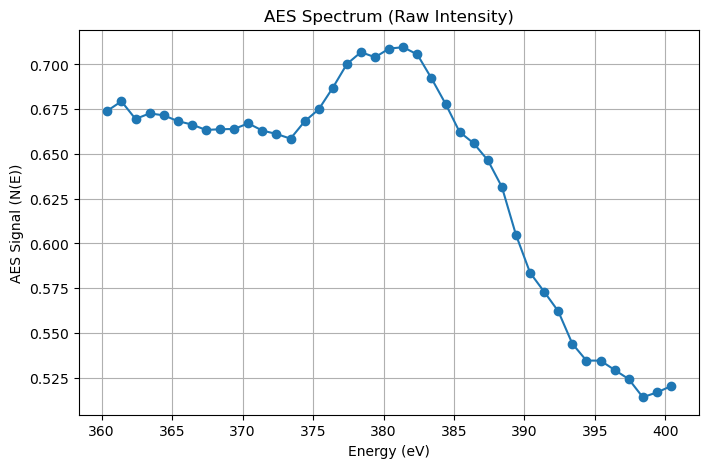

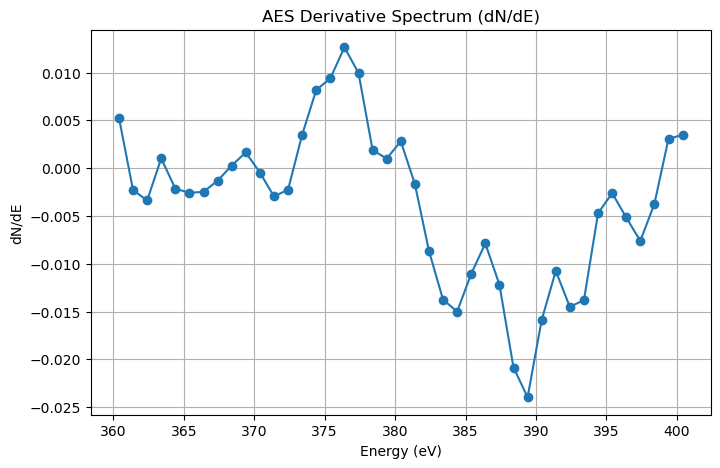

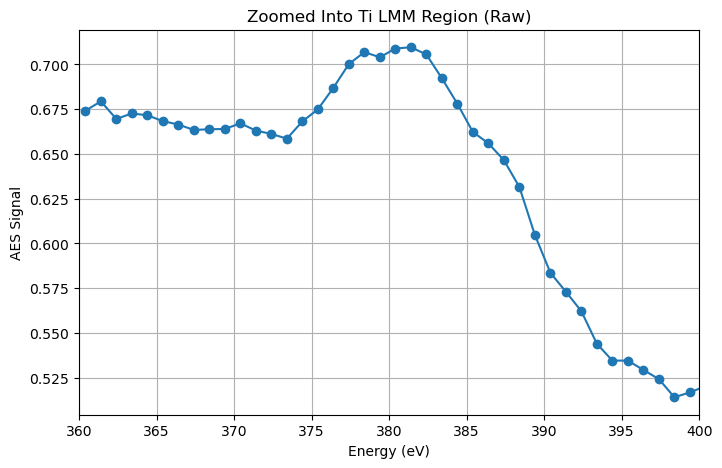

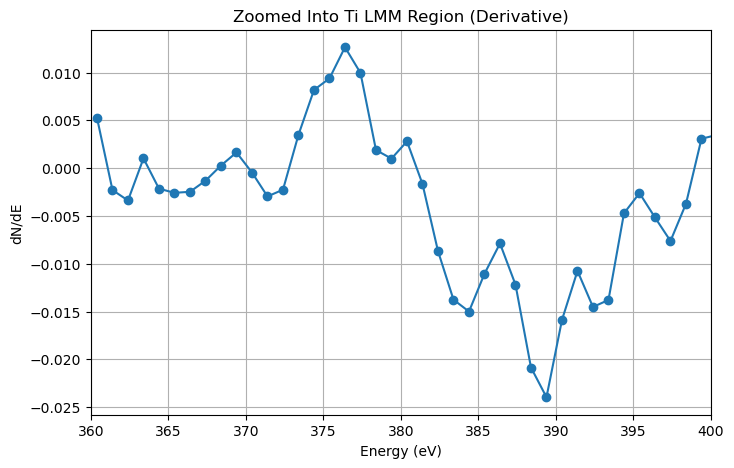

In [10]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Loader for Staib .lvm files
def load_lvm(path):
    raw_rows = []

    with open(path, "r", encoding="latin-1", errors="ignore") as f:
        for line in f:

            # Stop when header begins
            if line.strip().startswith("----------"):
                break

            parts = line.strip().split()
            if len(parts) == 0:
                continue

            try:
                nums = [float(x) for x in parts]
                raw_rows.append(nums)
            except:
                continue

    lengths = [len(r) for r in raw_rows]
    target_len = max(set(lengths), key=lengths.count)
    clean_rows = [r for r in raw_rows if len(r) == target_len]

    return np.array(clean_rows)


# ----------------------------------------------------------
# 2. Load the AES file
# ----------------------------------------------------------
path = "/Users/chloeisabella/Desktop/AES_Data/TiPeak_1mlSTO_TF268/1.lvm"
data = load_lvm(path)
print("Loaded shape:", data.shape)


# ----------------------------------------------------------
# 3. Extract AES spectrum
# ----------------------------------------------------------
energy = data[:, 1]   # eV axis (increasing)
signal = data[:, 2]   # AES amplitude (N(E))


# ----------------------------------------------------------
# 4. Plot RAW spectrum (NO inverted axis)
# ----------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(energy, signal, marker='o')
plt.xlabel("Energy (eV)")
plt.ylabel("AES Signal (N(E))")
plt.title("AES Spectrum (Raw Intensity)")
plt.grid(True)
plt.show()


# ----------------------------------------------------------
# 5. Compute DERIVATIVE (NO inverted axis)
# ----------------------------------------------------------
derivative = np.gradient(signal, energy)

plt.figure(figsize=(8,5))
plt.plot(energy, derivative, marker='o')
plt.xlabel("Energy (eV)")
plt.ylabel("dN/dE")
plt.title("AES Derivative Spectrum (dN/dE)")
plt.grid(True)
plt.show()


# ----------------------------------------------------------
# 6. Optional: zoom into Ti-LMM region (360–400 eV)
#     *Still not inverted — uses normal low→high direction*
# ----------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(energy, signal, marker='o')
plt.xlim(360, 400)   # normal order
plt.xlabel("Energy (eV)")
plt.ylabel("AES Signal")
plt.title("Zoomed Into Ti LMM Region (Raw)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(energy, derivative, marker='o')
plt.xlim(360, 400)
plt.xlabel("Energy (eV)")
plt.ylabel("dN/dE")
plt.title("Zoomed Into Ti LMM Region (Derivative)")
plt.grid(True)
plt.show()


# Data Auto-Selection

From my desktop, this code iterates through all the folders and subfolders in my main data file. And Since I'm deciding to focus on Ti peaks only, it will serarch for all auger scans for Ti peaks. I care about Ti peak its between 25-45 ev. And Sr peak is between 65-90 ev.

In [11]:
import os
import numpy as np

# --------------------------
# 1. LVM Loader (unchanged)
# --------------------------
def load_lvm(path):
    raw_rows = []
    with open(path, "r", encoding="latin-1", errors="ignore") as f:
        for line in f:
            if line.strip().startswith("----------"):
                break
            parts = line.strip().split()
            if len(parts) == 0:
                continue
            try:
                nums = [float(x) for x in parts]
                raw_rows.append(nums)
            except:
                continue
    if len(raw_rows) == 0:
        raise ValueError(f"No valid numeric rows in {path}")

    lengths = [len(r) for r in raw_rows]
    target_len = max(set(lengths), key=lengths.count)
    clean = [r for r in raw_rows if len(r) == target_len]

    return np.array(clean, dtype=float)


# --------------------------
# 2. Ti Folder Detection
# --------------------------
TI_KEYWORDS = ["ti", "titanium", "mv", "mvv", "ti_mvv", "ti-scan"]

def is_ti_folder(name):
    name = name.lower()
    return any(kw in name for kw in TI_KEYWORDS)


# --------------------------
# 3. Ti Energy Range
# --------------------------
# Ti MVV peak region (updated to 25-60 eV as per spec)
TI_RANGE = (25, 60)

def energy_overlaps(energy, low, high):
    return (energy.min() <= high) and (energy.max() >= low)


# --------------------------
# 4. Load ONLY Ti MVV scans
# --------------------------
def load_ti_scans(root_folder):
    ti_scans = []

    for root, dirs, files in os.walk(root_folder):
        folder_name = os.path.basename(root)

        # Only consider folders that look like Ti
        if not is_ti_folder(folder_name):
            continue

        for file in files:
            if not file.endswith(".lvm"):
                continue

            full_path = os.path.join(root, file)

            # Load data to check window
            arr = load_lvm(full_path)
            energy = arr[:,1]
            signal = arr[:,2]

            # Check if this scan is in the 25–60 eV Ti MVV region
            if not energy_overlaps(energy, *TI_RANGE):
                continue

            # Parse path pieces
            parts = full_path.split(os.sep)
            scan_number = file.replace(".lvm", "")
            element = "Ti"
            material = parts[-3]
            experiment = parts[-4]

            # Label example: TF288_TiO2_Ti1
            label = f"{experiment}_{material}_{element}{scan_number}"

            ti_scans.append({
                "label": label,
                "experiment": experiment,
                "material": material,
                "element": element,
                "scan_number": scan_number,
                "path": full_path,
                "energy": energy,
                "signal": signal,
            })

    return ti_scans


In [12]:
root = "/Users/chloeisabella/Desktop/Files for Yash"
ti_scans = load_ti_scans(root)

print("Total Ti (25–45 eV) scans found:", len(ti_scans))
for s in ti_scans[:10]:
    print(s["label"])


Total Ti (25–45 eV) scans found: 2091
TF268_5mlSTO_Ti5
TF268_5mlSTO_Ti4
TF268_5mlSTO_Ti3
TF268_5mlSTO_Ti2
TF268_5mlSTO_Ti1
TF268_15mlSTO_Ti5
TF268_15mlSTO_Ti4
TF268_15mlSTO_Ti3
TF268_15mlSTO_Ti2
TF268_15mlSTO_Ti1


In [13]:
# ============================================================================
# TEMPORAL TRAIN/TEST SPLIT
# ============================================================================

def group_scans_by_experiment_material(ti_scans):
    """Group scans by (experiment, material) combination."""
    groups = defaultdict(lambda: defaultdict(list))
    
    for i, rec in enumerate(ti_scans):
        exp = rec["experiment"]
        material = rec["material"]
        scan_num = int(rec["scan_number"])
        groups[exp][material].append((i, scan_num, rec))
    
    # Sort each group by scan_number
    for exp in groups:
        for material in groups[exp]:
            groups[exp][material].sort(key=lambda x: x[1])
    
    return groups


def create_temporal_split(ti_scans, train_scan_max=4):
    """
    Creates temporal train/test split.
    
    For each (experiment, material) group:
    - Train: scans 1 to train_scan_max (default: 1-4)
    - Test: scans (train_scan_max+1)+ (default: 5+)
    
    Returns:
        train_indices: list of global indices for training
        test_indices: list of global indices for testing
        train_groups: dict mapping (exp, material) to train scan numbers
        test_groups: dict mapping (exp, material) to test scan numbers
    """
    groups = group_scans_by_experiment_material(ti_scans)
    
    train_indices = []
    test_indices = []
    train_groups = {}
    test_groups = {}
    
    for exp in groups:
        for material in groups[exp]:
            scans = groups[exp][material]
            key = (exp, material)
            
            train_group = []
            test_group = []
            
            for global_idx, scan_num, rec in scans:
                if scan_num <= train_scan_max:
                    train_indices.append(global_idx)
                    train_group.append(scan_num)
                else:
                    test_indices.append(global_idx)
                    test_group.append(scan_num)
            
            if train_group:
                train_groups[key] = sorted(train_group)
            if test_group:
                test_groups[key] = sorted(test_group)
    
    print(f"Temporal Split Summary:")
    print(f"  Training scans: {len(train_indices)} (scans 1-{train_scan_max})")
    print(f"  Test scans: {len(test_indices)} (scan {train_scan_max+1}+)")
    print(f"  Experiment-material groups with training data: {len(train_groups)}")
    print(f"  Experiment-material groups with test data: {len(test_groups)}")
    
    return train_indices, test_indices, train_groups, test_groups


# Create the split
train_indices, test_indices, train_groups, test_groups = create_temporal_split(ti_scans, train_scan_max=4)

# Verify no overlap
assert len(set(train_indices) & set(test_indices)) == 0, "ERROR: Train and test sets overlap!"
print("\n✓ Temporal split verified: no data leakage")


Temporal Split Summary:
  Training scans: 1314 (scans 1-4)
  Test scans: 777 (scan 5+)
  Experiment-material groups with training data: 364
  Experiment-material groups with test data: 291

✓ Temporal split verified: no data leakage


## Checking that the selected data sets are accurate 

The following checks that the energy window of interest is correct for all these labeled scans - within 25 to 60 ev. And that the data is not distorted, and when plotted, looks accurate. The first 5 plots and their derivates are plotted below.

Energy window check (min/max eV):
TF268_5mlSTO_Ti5: 30.08  →  61.08
TF268_5mlSTO_Ti4: 30.08  →  61.08
TF268_5mlSTO_Ti3: 30.08  →  61.08
TF268_5mlSTO_Ti2: 30.08  →  61.08
TF268_5mlSTO_Ti1: 30.08  →  61.08
TF268_15mlSTO_Ti5: 30.08  →  61.08
TF268_15mlSTO_Ti4: 30.08  →  61.08
TF268_15mlSTO_Ti3: 30.08  →  61.08
TF268_15mlSTO_Ti2: 30.08  →  61.08
TF268_15mlSTO_Ti1: 30.08  →  61.08
TF268_9mlSTO_Ti1: 30.08  →  61.08
TF268_19mlSTO_Ti1: 30.08  →  61.08
TF268_18mlSTO_Ti1: 30.08  →  61.08
TF268_8mlSTO_Ti1: 30.08  →  61.08
TF268_14mlSTO_Ti1: 30.08  →  61.08
TF268_4mlSTO_Ti1: 30.08  →  61.08
TF268_3mlSTO_Ti1: 30.08  →  61.08
TF268_13mlSTO_Ti1: 30.08  →  61.08
TF268_12mlSTO_Ti1: 30.08  →  61.08
TF268_2mlSTO_Ti1: 30.08  →  61.08
TF268_11mlSTO_Ti1: 30.08  →  61.08
TF268_1mlSTO_Ti5: 30.08  →  61.08
TF268_1mlSTO_Ti4: 30.08  →  61.08
TF268_1mlSTO_Ti3: 30.08  →  61.08
TF268_1mlSTO_Ti2: 30.08  →  61.08
TF268_1mlSTO_Ti1: 30.08  →  61.08
TF268_10mlSTO_Ti5: 30.08  →  61.08
TF268_10mlSTO_Ti4: 30.08  →  61.08
T

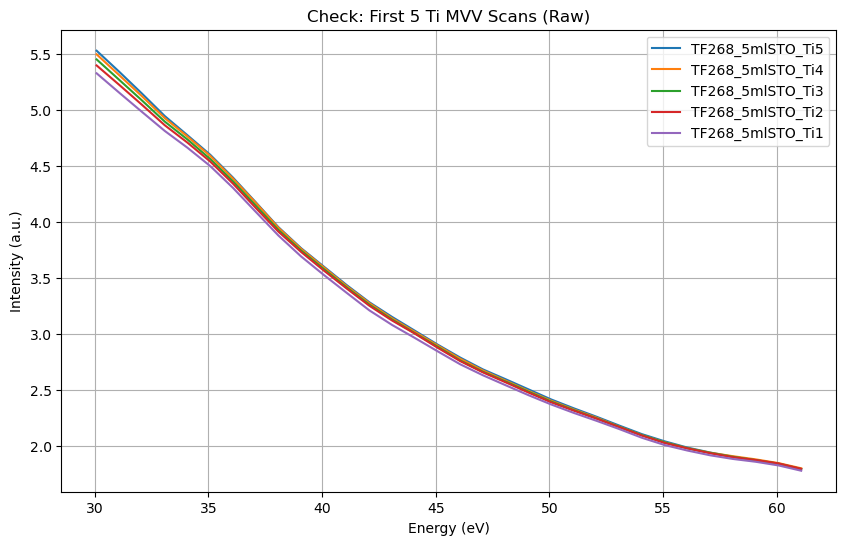

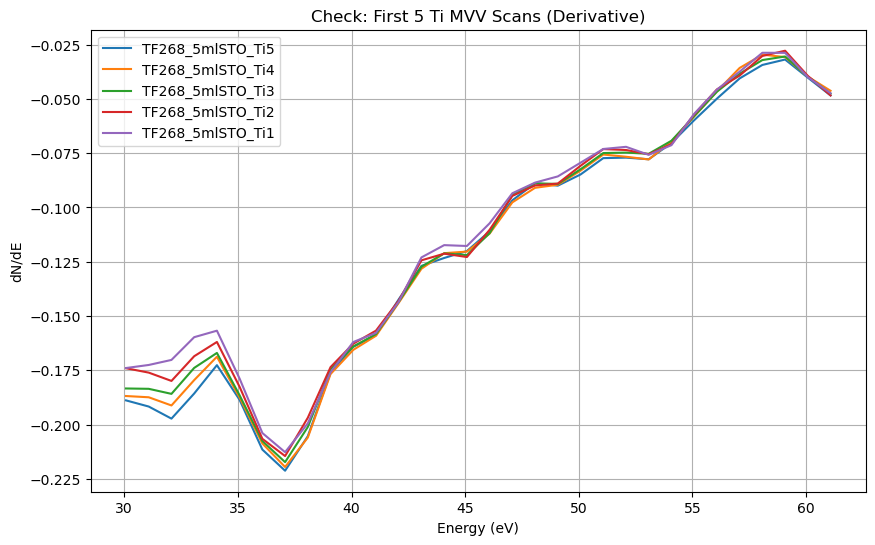


Energy spacing check:
TF268_5mlSTO_Ti5 spacing (first 5): [1. 1. 1. 1. 1.]
TF268_5mlSTO_Ti4 spacing (first 5): [1. 1. 1. 1. 1.]
TF268_5mlSTO_Ti3 spacing (first 5): [1. 1. 1. 1. 1.]


In [14]:
# -----------------------------------------
# 1. Print energy min/max for each Ti scan
# -----------------------------------------
print("Energy window check (min/max eV):")
for s in ti_scans:
    print(f"{s['label']}: {s['energy'].min():.2f}  →  {s['energy'].max():.2f}")
    

# -----------------------------------------
# 2. Plot the first 5 Ti scans (raw)
# -----------------------------------------
plt.figure(figsize=(10,6))
for s in ti_scans[:5]:
    plt.plot(s["energy"], s["signal"], label=s["label"])
plt.xlabel("Energy (eV)")
plt.ylabel("Intensity (a.u.)")
plt.title("Check: First 5 Ti MVV Scans (Raw)")
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------------------
# 3. Plot derivatives of first 5 scans
# -----------------------------------------
plt.figure(figsize=(10,6))
for s in ti_scans[:5]:
    der = np.gradient(s["signal"], s["energy"])
    plt.plot(s["energy"], der, label=s["label"])
plt.xlabel("Energy (eV)")
plt.ylabel("dN/dE")
plt.title("Check: First 5 Ti MVV Scans (Derivative)")
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------------------
# 4. Print first few energy spacings
# -----------------------------------------
print("\nEnergy spacing check:")
for s in ti_scans[:3]:
    print(f"{s['label']} spacing (first 5): {np.diff(s['energy'])[:5]}")


## Principal Component Analysis

Okay, we've now completed data selection and filtering. The next step in the pipeline is to perform PCA -> NN (Neural Network) -> BO (Bayesian Optimization). PCA is a dimensionality reduction method - you take a spectrum with 41+ energy points (e.g., 25–60 eV scan) and compress it into a small number of “latent features” that capture the most important variations. We do this because neural networks perform poorly on raw spectra (too high dimensional):

- BO absolutely cannot optimize 41-dimensional functions

- PCA discovers the underlying structure of the spectra

- PCA removes noise and baseline drift

- PCA forces the NN to learn only the meaningful shape changes in Ti MVV

If we run PCA, we get:

PC1 = average Ti MVV shape

PC2 = variation due to oxidation, band bending

PC3 = noise or differential changes

etc.

## Modular ML System: Base Model Interface

Define abstract base class for all temporal models to ensure consistent interface.


In [15]:
# ============================================================================
# BASE MODEL INTERFACE
# ============================================================================

class BaseTemporalModel(nn.Module, ABC):
    """Abstract base class for all temporal prediction models."""
    
    def __init__(self, latent_dim, **kwargs):
        super().__init__()
        self.latent_dim = latent_dim
    
    @abstractmethod
    def get_input_dim(self):
        """Return the input feature dimension."""
        pass
    
    @abstractmethod
    def get_hyperparameter_space(self):
        """Return Bayesian optimization search space as dict."""
        pass
    
    @abstractmethod
    def forward(self, x):
        """Forward pass."""
        pass


## Model Implementations

All models predict PCA latent vectors from temporal inputs. Each model has different strengths for time-series prediction.


In [16]:
# ============================================================================
# MODEL IMPLEMENTATIONS
# ============================================================================

# 1. Enhanced Feedforward NN (with experiment encoding)
class EnhancedNNModel(BaseTemporalModel):
    """Enhanced feedforward NN with experiment encoding."""
    
    def __init__(self, latent_dim, input_dim=2, hidden_dim=128, num_layers=3, dropout=0.1, **kwargs):
        super().__init__(latent_dim)
        self.input_dim = input_dim
        
        layers = []
        in_dim = input_dim
        for i in range(num_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        
        layers.append(nn.Linear(hidden_dim, latent_dim))
        self.net = nn.Sequential(*layers)
    
    def get_input_dim(self):
        return self.input_dim
    
    def get_hyperparameter_space(self):
        return {
            'lr': (1e-4, 5e-3),
            'hidden_dim': (32, 256),
            'num_layers': (2, 5),
            'dropout': (0.0, 0.3)
        }
    
    def forward(self, x):
        return self.net(x)


# 2. LSTM Model
class LSTMTemporalModel(BaseTemporalModel):
    """LSTM for sequence learning."""
    
    def __init__(self, latent_dim, input_dim=2, hidden_dim=128, num_layers=2, dropout=0.1, **kwargs):
        super().__init__(latent_dim)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, latent_dim)
    
    def get_input_dim(self):
        return self.input_dim
    
    def get_hyperparameter_space(self):
        return {
            'lr': (1e-4, 5e-3),
            'hidden_dim': (32, 256),
            'num_layers': (1, 3),
            'dropout': (0.0, 0.3)
        }
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_dim) or (batch, input_dim)
        if x.dim() == 2:
            x = x.unsqueeze(1)  # Add sequence dimension
        
        lstm_out, _ = self.lstm(x)
        # Take last timestep
        last_output = lstm_out[:, -1, :]
        return self.fc(last_output)


# 3. RNN Model
class RNNTemporalModel(BaseTemporalModel):
    """Basic RNN for sequence learning."""
    
    def __init__(self, latent_dim, input_dim=2, hidden_dim=128, num_layers=2, **kwargs):
        super().__init__(latent_dim)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, latent_dim)
    
    def get_input_dim(self):
        return self.input_dim
    
    def get_hyperparameter_space(self):
        return {
            'lr': (1e-4, 5e-3),
            'hidden_dim': (32, 256),
            'num_layers': (1, 3)
        }
    
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        
        rnn_out, _ = self.rnn(x)
        last_output = rnn_out[:, -1, :]
        return self.fc(last_output)


# 4. GRU Model
class GRUTemporalModel(BaseTemporalModel):
    """GRU (Gated Recurrent Unit) for sequence learning."""
    
    def __init__(self, latent_dim, input_dim=2, hidden_dim=128, num_layers=2, dropout=0.1, **kwargs):
        super().__init__(latent_dim)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, 
                         batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, latent_dim)
    
    def get_input_dim(self):
        return self.input_dim
    
    def get_hyperparameter_space(self):
        return {
            'lr': (1e-4, 5e-3),
            'hidden_dim': (32, 256),
            'num_layers': (1, 3),
            'dropout': (0.0, 0.3)
        }
    
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        
        gru_out, _ = self.gru(x)
        last_output = gru_out[:, -1, :]
        return self.fc(last_output)


# 5. Transformer Model
class TransformerTemporalModel(BaseTemporalModel):
    """Transformer with self-attention for temporal dependencies."""
    
    def __init__(self, latent_dim, input_dim=2, d_model=128, nhead=4, 
                 num_layers=2, dim_feedforward=256, dropout=0.1, **kwargs):
        super().__init__(latent_dim)
        self.input_dim = input_dim
        self.d_model = d_model
        
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, 100, d_model))  # Max seq len 100
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, latent_dim)
    
    def get_input_dim(self):
        return self.input_dim
    
    def get_hyperparameter_space(self):
        return {
            'lr': (1e-4, 5e-3),
            'd_model': (64, 256),
            'nhead': (2, 8),
            'num_layers': (1, 4),
            'dim_feedforward': (128, 512),
            'dropout': (0.0, 0.3)
        }
    
    def forward(self, x):
        # x: (batch, input_dim) or (batch, seq_len, input_dim)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        
        batch_size, seq_len, _ = x.shape
        x = self.input_proj(x)  # (batch, seq_len, d_model)
        x = x + self.pos_encoder[:, :seq_len, :]
        
        # Transformer expects (seq_len, batch, d_model) or (batch, seq_len, d_model) with batch_first=True
        x = self.transformer(x)
        # Take last timestep
        last_output = x[:, -1, :]
        return self.fc(last_output)


# 6. Temporal Convolutional Network (TCN)
class TCNTemporalModel(BaseTemporalModel):
    """Temporal Convolutional Network with causal convolutions."""
    
    def __init__(self, latent_dim, input_dim=2, num_filters=64, kernel_size=3, 
                 num_layers=3, dropout=0.1, **kwargs):
        super().__init__(latent_dim)
        self.input_dim = input_dim
        
        layers = []
        in_channels = input_dim
        for i in range(num_layers):
            dilation = 2 ** i
            padding = (kernel_size - 1) * dilation
            layers.append(nn.Conv1d(in_channels, num_filters, kernel_size, 
                                   dilation=dilation, padding=padding))
            layers.append(nn.BatchNorm1d(num_filters))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_channels = num_filters
        
        self.conv_layers = nn.Sequential(*layers)
        self.fc = nn.Linear(num_filters, latent_dim)
    
    def get_input_dim(self):
        return self.input_dim
    
    def get_hyperparameter_space(self):
        return {
            'lr': (1e-4, 5e-3),
            'num_filters': (32, 128),
            'kernel_size': (2, 5),
            'num_layers': (2, 5),
            'dropout': (0.0, 0.3)
        }
    
    def forward(self, x):
        # x: (batch, input_dim) or (batch, seq_len, input_dim)
        if x.dim() == 2:
            x = x.unsqueeze(1)  # (batch, 1, input_dim)
        else:
            x = x.transpose(1, 2)  # (batch, input_dim, seq_len)
        
        x = self.conv_layers(x)
        # Take last timestep (causal padding ensures no future leakage)
        x = x[:, :, -1]  # (batch, num_filters)
        return self.fc(x)


print("All model classes defined successfully!")


All model classes defined successfully!


## Model Registry & Experiment Encoding

Registry for easy model access and experiment encoding for temporal-aware inputs.


In [17]:
# ============================================================================
# MODEL REGISTRY
# ============================================================================

MODEL_REGISTRY = {
    'nn': EnhancedNNModel,
    'lstm': LSTMTemporalModel,
    'rnn': RNNTemporalModel,
    'gru': GRUTemporalModel,
    'transformer': TransformerTemporalModel,
    'tcn': TCNTemporalModel,
}

def get_model_class(model_name):
    """Get model class from registry."""
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model: {model_name}. Available: {list(MODEL_REGISTRY.keys())}")
    return MODEL_REGISTRY[model_name]


# ============================================================================
# EXPERIMENT ENCODING
# ============================================================================

def create_experiment_encoder(ti_scans):
    """Create label encoder for experiments."""
    experiments = [rec["experiment"] for rec in ti_scans]
    encoder = LabelEncoder()
    encoder.fit(experiments)
    return encoder


def prepare_temporal_inputs(ti_scans, train_indices, test_indices, exp_encoder):
    """
    Prepare temporal-aware inputs: (experiment_id, scan_number).
    
    Returns:
        X_train, y_train, X_test, y_test as numpy arrays
    """
    # Encode experiments
    exp_ids = exp_encoder.transform([ti_scans[i]["experiment"] for i in range(len(ti_scans))])
    scan_nums = np.array([int(ti_scans[i]["scan_number"]) for i in range(len(ti_scans))])
    
    # Create inputs: (experiment_id, scan_number)
    X = np.column_stack([exp_ids, scan_nums]).astype(np.float32)
    
    # Split
    X_train = X[train_indices]
    X_test = X[test_indices]
    
    return X_train, X_test


print("Model registry and encoding utilities ready!")


Model registry and encoding utilities ready!


## Training Framework with Bayesian Optimization

Framework for training models with BO, using proper temporal train/val split.


In [18]:
# ============================================================================
# TRAINING FRAMEWORK
# ============================================================================

def train_model_with_bo(model_class, X_train, y_train, X_val, y_val, 
                        latent_dim, input_dim, bo_iterations=15, bo_init_points=5,
                        train_epochs=300, device='cpu'):
    """
    Train a model with Bayesian Optimization.
    
    Returns:
        best_model: Trained model with best hyperparameters
        best_params: Best hyperparameters found
        bo_optimizer: BayesianOptimization object
    """
    X_train_tensor = torch.tensor(X_train).to(device)
    y_train_tensor = torch.tensor(y_train).to(device)
    X_val_tensor = torch.tensor(X_val).to(device)
    y_val_tensor = torch.tensor(y_val).to(device)
    
    # Get hyperparameter space
    temp_model = model_class(latent_dim=latent_dim, input_dim=input_dim)
    pbounds = temp_model.get_hyperparameter_space()
    del temp_model
    
    def objective(**params):
        """BO objective: train model and return negative validation loss."""
        # Get learning rate (remove from params for model init)
        params_copy = params.copy()
        lr = params_copy.pop('lr', 1e-3)
        
        # Create model with current hyperparameters
        model = model_class(latent_dim=latent_dim, input_dim=input_dim, **params_copy)
        model = model.to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        
        # Train
        model.train()
        for epoch in range(train_epochs):
            pred = model(X_train_tensor)
            loss = loss_fn(pred, y_train_tensor)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_tensor)
            val_loss = loss_fn(val_pred, y_val_tensor).item()
        
        # BO maximizes, so return negative loss
        return -val_loss
    
    # Run Bayesian Optimization
    optimizer = BayesianOptimization(
        f=objective,
        pbounds=pbounds,
        random_state=42,
        verbose=1
    )
    
    optimizer.maximize(init_points=bo_init_points, n_iter=bo_iterations)
    
    # Get best parameters
    best_params = optimizer.max['params'].copy()
    best_lr = best_params.pop('lr', 1e-3)
    
    # Train final model with best parameters
    best_model = model_class(latent_dim=latent_dim, input_dim=input_dim, **best_params)
    best_model = best_model.to(device)
    best_optimizer = torch.optim.Adam(best_model.parameters(), lr=best_lr)
    loss_fn = nn.MSELoss()
    
    print(f"\nTraining final model with best params: lr={best_lr:.6f}, {best_params}")
    
    best_model.train()
    for epoch in range(train_epochs * 2):  # Train longer for final model
        pred = best_model(X_train_tensor)
        loss = loss_fn(pred, y_train_tensor)
        best_optimizer.zero_grad()
        loss.backward()
        best_optimizer.step()
        
        if (epoch + 1) % 100 == 0:
            best_model.eval()
            with torch.no_grad():
                val_pred = best_model(X_val_tensor)
                val_loss = loss_fn(val_pred, y_val_tensor).item()
            print(f"  Epoch {epoch+1}, Val Loss: {val_loss:.6f}")
            best_model.train()
    
    best_model.eval()
    return best_model, best_params, optimizer


print("Training framework ready!")


Training framework ready!


## Model Comparison Framework

Compare multiple models on the same test set with consistent metrics.


In [19]:
# ============================================================================
# MODEL COMPARISON FRAMEWORK
# ============================================================================

def compute_metrics(y_true, y_pred):
    """Compute regression metrics."""
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(mse)
    
    # R² score
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Correlation
    corr = np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]
    
    return {
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Correlation': corr
    }


class ModelComparison:
    """Compare multiple models on the same test set."""
    
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, 
                 latent_dim, input_dim, device='cpu'):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.device = device
        self.results = {}
        self.models = {}
    
    def train_and_evaluate(self, model_names, bo_iterations=10, bo_init_points=3, train_epochs=200):
        """Train multiple models and evaluate on test set."""
        for model_name in model_names:
            print(f"\n{'='*60}")
            print(f"Training {model_name.upper()} model")
            print(f"{'='*60}")
            
            model_class = get_model_class(model_name)
            
            # Train with BO
            model, best_params, bo_opt = train_model_with_bo(
                model_class, self.X_train, self.y_train, self.X_val, self.y_val,
                self.latent_dim, self.input_dim,
                bo_iterations=bo_iterations, bo_init_points=bo_init_points,
                train_epochs=train_epochs, device=self.device
            )
            
            # Evaluate on test set
            X_test_tensor = torch.tensor(self.X_test).to(self.device)
            model.eval()
            with torch.no_grad():
                y_pred_test = model(X_test_tensor).cpu().numpy()
            
            # Compute metrics
            metrics = compute_metrics(self.y_test, y_pred_test)
            
            # Store results
            self.results[model_name] = {
                'metrics': metrics,
                'best_params': best_params,
                'bo_optimizer': bo_opt,
                'y_pred': y_pred_test
            }
            self.models[model_name] = model
            
            print(f"\n{model_name.upper()} Test Metrics:")
            for key, value in metrics.items():
                print(f"  {key}: {value:.6f}")
        
        return self.results
    
    def get_comparison_dataframe(self):
        """Get comparison results as DataFrame."""
        data = {}
        for model_name, result in self.results.items():
            for metric, value in result['metrics'].items():
                if metric not in data:
                    data[metric] = {}
                data[metric][model_name] = value
        
        return pd.DataFrame(data)
    
    def plot_comparison(self, metric='RMSE'):
        """Plot comparison of models for a given metric."""
        df = self.get_comparison_dataframe()
        
        if metric not in df.columns:
            print(f"Metric {metric} not found. Available: {list(df.columns)}")
            return
        
        plt.figure(figsize=(10, 6))
        df[metric].plot(kind='bar')
        plt.title(f'Model Comparison: {metric}')
        plt.ylabel(metric)
        plt.xlabel('Model')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def plot_predictions(self, model_name, n_samples=5):
        """Plot predictions vs actual for a model."""
        if model_name not in self.results:
            print(f"Model {model_name} not found in results.")
            return
        
        y_pred = self.results[model_name]['y_pred']
        
        # Sample random test indices
        n_samples = min(n_samples, len(self.y_test))
        indices = np.random.choice(len(self.y_test), n_samples, replace=False)
        
        fig, axes = plt.subplots(1, n_samples, figsize=(5*n_samples, 4))
        if n_samples == 1:
            axes = [axes]
        
        for idx, ax in zip(indices, axes):
            ax.plot(self.y_test[idx], label='Actual', linewidth=2)
            ax.plot(y_pred[idx], '--', label='Predicted', linewidth=2)
            ax.set_title(f'Test Sample {idx}')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.suptitle(f'{model_name.upper()} Predictions vs Actual', fontsize=14)
        plt.tight_layout()
        plt.show()


print("Model comparison framework ready!")


Model comparison framework ready!


## Updated Prediction API

User-friendly functions for predicting scans with any model, ensuring no data leakage.


In [20]:
# ============================================================================
# PREDICTION API
# ============================================================================

def group_scans_by_experiment(ti_scans):
    """Group scans by experiment (for backward compatibility)."""
    scans_by_exp = defaultdict(list)
    for rec in ti_scans:
        exp = rec["experiment"]
        scan_num = int(rec["scan_number"])
        rec["scan_number"] = scan_num
        scans_by_exp[exp].append(rec)
    
    # Sort each experiment's scans by scan_number
    for exp in scans_by_exp:
        scans_by_exp[exp] = sorted(scans_by_exp[exp], key=lambda x: x["scan_number"])
    
    return scans_by_exp


def predict_scan(experiment_name, scan_number=5, model=None, model_name='nn',
                 ti_scans=None, scans_by_folder=None, pca=None, common_energy=None,
                 exp_encoder=None, device='cpu'):
    """
    Predict scan N for a given experiment using a trained model.
    
    Args:
        experiment_name: Experiment name (e.g., 'TF268')
        scan_number: Scan number to predict (default: 5)
        model: Trained model (if None, will try to use model_name from comparison)
        model_name: Model name if model not provided
        ti_scans: List of all scan records
        scans_by_folder: Grouped scans by experiment
        pca: Fitted PCA object
        common_energy: Common energy grid
        exp_encoder: Experiment encoder
        device: Device to run on
    
    Returns:
        common_energy, actual_norm, pred_norm
    """
    if scans_by_folder is None:
        scans_by_folder = group_scans_by_experiment(ti_scans)
    
    if experiment_name not in scans_by_folder:
        raise ValueError(f"Experiment {experiment_name} not found. Available: {list(scans_by_folder.keys())}")
    
    folder_scans = scans_by_folder[experiment_name]
    
    if len(folder_scans) < scan_number:
        raise ValueError(f"{experiment_name} only has {len(folder_scans)} scans. Cannot predict scan {scan_number}.")
    
    # Get actual scan
    actual_rec = folder_scans[scan_number - 1]  # 0-based index
    actual_energy = actual_rec["energy"]
    actual_signal = actual_rec["signal"]
    
    # Verify this scan is in test set (not trained on)
    global_index = ti_scans.index(actual_rec)
    if global_index not in test_indices:
        print(f"⚠️  Warning: Scan {scan_number} from {experiment_name} was in training set!")
        print(f"   This prediction may have data leakage.")
    
    # Prepare input: (experiment_id, scan_number)
    exp_id = exp_encoder.transform([experiment_name])[0]
    scan_num = float(scan_number)
    X_input = np.array([[exp_id, scan_num]], dtype=np.float32)
    
    # Predict
    if model is None:
        # Try to get from comparison if available
        if 'comparison' in globals() and model_name in comparison.models:
            model = comparison.models[model_name]
        else:
            raise ValueError(f"Model not provided and {model_name} not found in comparison. Please train a model first.")
    
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_input).to(device)
        latent_pred = model(X_tensor).cpu().numpy()
    
    # Reconstruct spectrum
    pred_norm = pca.inverse_transform(latent_pred)[0]
    
    # Get actual normalized spectrum
    actual_resampled = resample_spectrum(actual_energy, actual_signal, common_energy)
    actual_norm = actual_resampled / np.max(actual_resampled)
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(common_energy, actual_norm, label="Actual", linewidth=2)
    plt.plot(common_energy, pred_norm, "--", label="Predicted", linewidth=2)
    plt.xlabel("Energy (eV)")
    plt.ylabel("Normalized Intensity")
    plt.title(f"{experiment_name} — Scan {scan_number}: Actual vs Predicted ({model_name.upper()})")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    return common_energy, actual_norm, pred_norm


def plot_derivative(experiment_name, scan_number=5, model=None, model_name='nn', **kwargs):
    """Plot derivative comparison for a predicted scan."""
    energy, actual_norm, pred_norm = predict_scan(
        experiment_name, scan_number, model=model, model_name=model_name, **kwargs
    )
    
    d_actual = np.gradient(actual_norm, energy)
    d_pred = np.gradient(pred_norm, energy)
    
    plt.figure(figsize=(10, 5))
    plt.plot(energy, d_actual, label="Actual dN/dE", linewidth=2)
    plt.plot(energy, d_pred, "--", label="Predicted dN/dE", linewidth=2)
    plt.xlabel("Energy (eV)")
    plt.ylabel("dN/dE")
    plt.title(f"{experiment_name} — Scan {scan_number}: Derivative Comparison")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    return d_actual, d_pred


def train_and_compare_models(model_names=['nn', 'lstm', 'gru'], 
                              X_train=None, y_train=None, X_val=None, y_val=None,
                              X_test=None, y_test=None, latent_dim=5, input_dim=2,
                              bo_iterations=10, bo_init_points=3, train_epochs=200,
                              device='cpu'):
    """
    Convenience function to train and compare multiple models.
    
    Returns:
        ModelComparison object with trained models and results
    """
    if X_train is None:
        # Use global variables if not provided
        X_train = globals().get('X_train')
        y_train = globals().get('y_train')
        X_val = globals().get('X_val')
        y_val = globals().get('y_val')
        X_test = globals().get('X_test')
        y_test = globals().get('y_test')
        latent_dim = globals().get('latent_dim', 5)
        input_dim = globals().get('input_dim', 2)
    
    comparison = ModelComparison(
        X_train, y_train, X_val, y_val, X_test, y_test,
        latent_dim, input_dim, device=device
    )
    
    comparison.train_and_evaluate(
        model_names, 
        bo_iterations=bo_iterations,
        bo_init_points=bo_init_points,
        train_epochs=train_epochs
    )
    
    return comparison


print("Prediction API ready!")


Prediction API ready!


## Data Setup with Temporal Split

Set up preprocessing with proper temporal train/val/test splits. This replaces the old preprocessing to ensure no data leakage.


In [21]:
# ============================================================================
# PREPROCESSING WITH TEMPORAL SPLIT
# ============================================================================

# Resample and normalize (same as before)
ENERGY_MIN = 25
ENERGY_MAX = 60
STEP = 0.1
common_energy = np.arange(ENERGY_MIN, ENERGY_MAX + STEP, STEP)

resampled_spectra = []
for s in ti_scans:
    resampled = resample_spectrum(s["energy"], s["signal"], common_energy)
    resampled_spectra.append(resampled)
resampled_spectra = np.array(resampled_spectra)

norm_spectra = resampled_spectra / np.max(resampled_spectra, axis=1, keepdims=True)

print(f"Resampled spectra shape: {resampled_spectra.shape}")
print(f"Normalized spectra shape: {norm_spectra.shape}")

# CRITICAL: Fit PCA only on training data
pca = PCA(n_components=5)
latent_train = pca.fit_transform(norm_spectra[train_indices])
latent_test = pca.transform(norm_spectra[test_indices])

# Create full latent array for compatibility
latent = np.zeros((len(norm_spectra), 5))
latent[train_indices] = latent_train
latent[test_indices] = latent_test

print(f"\n✓ PCA fitted only on training data (no data leakage)")
print(f"  Training latent shape: {latent_train.shape}")
print(f"  Test latent shape: {latent_test.shape}")

# Create validation split from training data (80/20 split)
train_idx_subset, val_idx_subset = train_test_split(
    np.arange(len(train_indices)), test_size=0.2, random_state=42
)

# Map back to global indices
val_indices_global = [train_indices[i] for i in val_idx_subset]
train_indices_final = [train_indices[i] for i in train_idx_subset]

# Prepare temporal-aware inputs
exp_encoder = create_experiment_encoder(ti_scans)

# Training set
X_train_full = prepare_temporal_inputs(ti_scans, train_indices, test_indices, exp_encoder)[0]
y_train_full = latent_train.astype(np.float32)

# Split training into train/val
X_train = X_train_full[train_idx_subset]
X_val = X_train_full[val_idx_subset]
y_train = y_train_full[train_idx_subset]
y_val = y_train_full[val_idx_subset]

# Test set
X_test = prepare_temporal_inputs(ti_scans, train_indices, test_indices, exp_encoder)[1]
y_test = latent_test.astype(np.float32)

# Store dimensions
latent_dim = 5
input_dim = 2

print(f"\n✓ Temporal split complete:")
print(f"  Training: {len(X_train)} samples (scans 1-4)")
print(f"  Validation: {len(X_val)} samples (from training set)")
print(f"  Test: {len(X_test)} samples (scan 5+)")
print(f"  Input dimension: {input_dim} (experiment_id, scan_number)")
print(f"  Output dimension: {latent_dim} (PCA latent)")

# Store scans_by_folder for prediction API
scans_by_folder = group_scans_by_experiment(ti_scans)

print("\n✓ All data prepared and ready for training!")


NameError: name 'resample_spectrum' is not defined

## Example Usage

Train and compare models, then make predictions.


In [ ]:
# ============================================================================
# EXAMPLE: Train and Compare Models
# ============================================================================

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Train and compare models (start with a few for faster testing)
# You can add more models: ['nn', 'lstm', 'rnn', 'gru', 'transformer', 'tcn']
model_names_to_train = ['nn', 'lstm', 'gru']  # Start with these

print(f"\nTraining models: {model_names_to_train}")
print("This may take a while...")

comparison = train_and_compare_models(
    model_names=model_names_to_train,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    latent_dim=latent_dim, input_dim=input_dim,
    bo_iterations=10,  # Reduce for faster testing
    bo_init_points=3,
    train_epochs=200,
    device=device
)

# Display comparison results
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
comparison_df = comparison.get_comparison_dataframe()
print(comparison_df)

# Plot comparison
comparison.plot_comparison(metric='RMSE')
comparison.plot_comparison(metric='R²')
comparison.plot_comparison(metric='Correlation')


## Make Predictions

Use the trained models to predict scan 5 for any experiment.


In [ ]:
# ============================================================================
# EXAMPLE: Make Predictions
# ============================================================================

# Predict scan 5 for TF268 using the best model (or specify model_name)
experiment = "TF268"
scan_num = 5

# Use a specific model
model_name_to_use = 'lstm'  # or 'nn', 'gru', etc.

print(f"Predicting {experiment} scan {scan_num} using {model_name_to_use.upper()} model...")

energy, actual, predicted = predict_scan(
    experiment_name=experiment,
    scan_number=scan_num,
    model_name=model_name_to_use,
    ti_scans=ti_scans,
    scans_by_folder=scans_by_folder,
    pca=pca,
    common_energy=common_energy,
    exp_encoder=exp_encoder,
    device=device
)

# Plot derivative
plot_derivative(
    experiment_name=experiment,
    scan_number=scan_num,
    model_name=model_name_to_use,
    ti_scans=ti_scans,
    scans_by_folder=scans_by_folder,
    pca=pca,
    common_energy=common_energy,
    exp_encoder=exp_encoder,
    device=device
)


## Summary

This notebook implements a complete ML pipeline with:

✅ **Temporal Sequence Fixes:**
- Proper train/test split (scans 1-4 for training, scan 5+ for testing)
- No data leakage - PCA fitted only on training data
- Temporal-aware inputs (experiment_id, scan_number)

✅ **Modular ML System:**
- 6 different models: NN, LSTM, RNN, GRU, Transformer, TCN
- Easy model swapping via registry
- Bayesian optimization for hyperparameter tuning

✅ **Model Comparison:**
- Consistent evaluation metrics (MSE, MAE, RMSE, R², Correlation)
- Side-by-side performance comparison
- Visualization tools

✅ **User-Friendly API:**
- `train_and_compare_models()` - Train multiple models at once
- `predict_scan()` - Predict any scan with any model
- `plot_derivative()` - Visualize derivative comparisons

### Quick Start:
```python
# Train and compare models
comparison = train_and_compare_models(['nn', 'lstm', 'gru'])

# Make predictions
energy, actual, predicted = predict_scan("TF268", scan_number=5, model_name='lstm')
```


Need to do some resampling here, PCA requires:

- same feature vector length

- same meaning for each entry

- aligned energy points

My spectra originally had:

- different energy starting points

- different ending points

- different sampling resolution

Resampling fixes all of this.

In [ ]:
# ---------------------------------------------------------
# 1. RESAMPLE to a common (25–60 eV) energy grid
# ---------------------------------------------------------

ENERGY_MIN = 25
ENERGY_MAX = 60
STEP = 0.1

common_energy = np.arange(ENERGY_MIN, ENERGY_MAX + STEP, STEP)
print("Common grid length:", len(common_energy))


def resample_spectrum(energy, signal, common_energy):
    mask = (energy >= common_energy.min()) & (energy <= common_energy.max())
    energy = energy[mask]
    signal = signal[mask]
    return np.interp(common_energy, energy, signal)


# Resample all Ti scans
resampled_spectra = []

for s in ti_scans:
    resampled = resample_spectrum(s["energy"], s["signal"], common_energy)
    resampled_spectra.append(resampled)

resampled_spectra = np.array(resampled_spectra)
print("Resampled matrix:", resampled_spectra.shape)


# ---------------------------------------------------------
# 2. NORMALIZE each spectrum so max = 1
#    (This fixes your intensity mismatch issue)
# ---------------------------------------------------------

norm_spectra = resampled_spectra / np.max(resampled_spectra, axis=1, keepdims=True)

print("Normalized spectra shape:", norm_spectra.shape)


# ---------------------------------------------------------
# 3. PCA (compress spectra → latent vectors)
# ---------------------------------------------------------

pca = PCA(n_components=5)
latent = pca.fit_transform(norm_spectra)

print("Latent shape:", latent.shape)


## Building surrogate NN model

This NN will learn: (scan index)  →  (PCA latent vector)

And then we can reconstruct spectra using: predicted_latent → pca.inverse_transform() → predicted spectrum

This NN will become the model that Bayesian Optimization tunes next.

In [ ]:
# ---------------------------------------------------------
# 4. Prepare Neural Network inputs
#    X = scan index, y = PCA latent vector
# ---------------------------------------------------------

X = np.arange(len(latent)).reshape(-1, 1).astype(np.float32)
y = latent.astype(np.float32)

X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)


# ---------------------------------------------------------
# 5. Define Neural Network model
# ---------------------------------------------------------

class TiNet(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        
    def forward(self, x):
        return self.net(x)


latent_dim = latent.shape[1]
model = TiNet(latent_dim)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


# ---------------------------------------------------------
# 6. Train the neural network
# ---------------------------------------------------------

num_epochs = 2000

for epoch in range(num_epochs):
    model.train()
    pred = model(X_tensor)
    loss = loss_fn(pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")


# ---------------------------------------------------------
# 7. Predict latent vectors + reconstruct spectra
# ---------------------------------------------------------

model.eval()
with torch.no_grad():
    latent_pred = model(X_tensor).numpy()

reconstructed = pca.inverse_transform(latent_pred)

Let's check what the plots randomly look like:

In [ ]:
indices_to_plot = [
    0,
    len(latent) // 2,
    len(latent) - 1
]

for idx in indices_to_plot:
    plt.figure(figsize=(10, 5))
    plt.plot(common_energy, norm_spectra[idx], label="Actual", linewidth=2)
    plt.plot(common_energy, reconstructed[idx], "--", label="NN Predicted", linewidth=2)
    plt.xlabel("Energy (eV)")
    plt.ylabel("Normalized Intensity")
    plt.title(f"Scan {idx}: Actual vs NN Reconstruction")
    plt.legend()
    plt.grid(True)
    plt.show()

## Bayesian Optimization of the Surrogate NN Model

In [ ]:
from bayes_opt import BayesianOptimization
import torch
import torch.nn as nn
import numpy as np

# ---------------------------------------------------------
# Helper: Build + train model for given hyperparameters
# ---------------------------------------------------------

def train_model(lr, hidden_dim):
    lr = float(lr)
    hidden_dim = int(hidden_dim)

    # Build model
    class TiNet(nn.Module):
        def __init__(self, latent_dim, hidden_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(1, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, latent_dim)
            )
        def forward(self, x):
            return self.net(x)

    model = TiNet(latent_dim=latent.shape[1], hidden_dim=hidden_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Train briefly (BO uses a lightweight version)
    EPOCHS = 300

    for epoch in range(EPOCHS):
        model.train()
        pred = model(X_tensor)
        loss = loss_fn(pred, y_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # After training, compute final loss (lower = better)
    model.eval()
    with torch.no_grad():
        pred = model(X_tensor)
        final_loss = loss_fn(pred, y_tensor).item()

    # BO tries to MAXIMIZE objective → return negative loss
    return -final_loss


# ---------------------------------------------------------
#  BO Search Space
# ---------------------------------------------------------
pbounds = {
    'lr': (1e-4, 5e-3),         # learning rate
    'hidden_dim': (32, 256),    # network width
}

optimizer = BayesianOptimization(
    f=train_model,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

# ---------------------------------------------------------
# Run Bayesian Optimization
# ---------------------------------------------------------

optimizer.maximize(
    init_points=5,    # random trials
    n_iter=15         # BO iterations
)

print("Best Parameters Found:")
print(optimizer.max)


## Full re-training using the BO parameters

In [ ]:
# ---------------------------------------------------------
# 1. Extract best hyperparameters
# ---------------------------------------------------------

best_lr = float(optimizer.max['params']['lr'])
best_h = int(optimizer.max['params']['hidden_dim'])

print("Using Best LR:", best_lr)
print("Using Best Hidden Dim:", best_h)


# ---------------------------------------------------------
# 2. Rebuild model with optimal architecture
# ---------------------------------------------------------

class TiNetFinal(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
    def forward(self, x):
        return self.net(x)

model_final = TiNetFinal(latent_dim=latent.shape[1], hidden_dim=best_h)
optimizer_final = torch.optim.Adam(model_final.parameters(), lr=best_lr)
loss_fn = nn.MSELoss()


# ---------------------------------------------------------
# 3. Full training (2000 epochs or more)
# ---------------------------------------------------------

EPOCHS = 2000

for epoch in range(EPOCHS):
    model_final.train()
    pred = model_final(X_tensor)
    loss = loss_fn(pred, y_tensor)

    optimizer_final.zero_grad()
    loss.backward()
    optimizer_final.step()

    if epoch % 200 == 0:
        print(f"[FINAL] Epoch {epoch}, Loss = {loss.item():.6f}")


# ---------------------------------------------------------
# 4. Predict latent + reconstruct spectra
# ---------------------------------------------------------

model_final.eval()
with torch.no_grad():
    latent_pred_final = model_final(X_tensor).numpy()

reconstructed_final = pca.inverse_transform(latent_pred_final)


# ---------------------------------------------------------
# 5. Plot actual vs predicted for 3 scans
# ---------------------------------------------------------

indices_to_plot = [
    0,
    len(latent) // 2,
    len(latent) - 1
]

for idx in indices_to_plot:
    plt.figure(figsize=(10, 5))
    plt.plot(common_energy, norm_spectra[idx], label="Actual (Normalized)", linewidth=2)
    plt.plot(common_energy, reconstructed_final[idx], '--', label="NN Predicted (Optimized)", linewidth=2)
    plt.xlabel("Energy (eV)")
    plt.ylabel("Normalized Intensity")
    plt.title(f"[Optimized] Scan {idx}: Actual vs Predicted")
    plt.legend()
    plt.grid(True)
    plt.show()


# Testing The Prediction

In [ ]:
## Group scans by experiment folder (TF268, TF288, etc.)

from collections import defaultdict

def group_scans_by_experiment(ti_scans):
    scans_by_exp = defaultdict(list)

    for rec in ti_scans:
        exp = rec["experiment"]            # <-- TF268, TF288, etc.
        scan_num = int(rec["scan_number"]) # <-- convert "5" → 5
        rec["scan_number"] = scan_num      # <-- overwrite as int
        scans_by_exp[exp].append(rec)

    # Sort each experiment's scans by scan_number
    for exp in scans_by_exp:
        scans_by_exp[exp] = sorted(scans_by_exp[exp], key=lambda x: x["scan_number"])

    return scans_by_exp

scans_by_folder = group_scans_by_experiment(ti_scans)


# Main function: predict scan N within a chosen experiment

import matplotlib.pyplot as plt
import torch
import numpy as np

def predict_scan(folder_name, scan_number=5):
    """
    Predict scan #scan_number for a given TF folder (e.g., 'TF268').
    Uses BO-optimized neural network and compares to actual scan.
    """

    if folder_name not in scans_by_folder:
        raise ValueError(f"Folder {folder_name} not found. Available: {list(scans_by_folder.keys())}")

    folder_scans = scans_by_folder[folder_name]

    if len(folder_scans) < scan_number:
        raise ValueError(f"{folder_name} only has {len(folder_scans)} scans. Cannot predict scan {scan_number}.")

    print(f"\n📂 Experiment: {folder_name}")
    print(f"Predicting scan {scan_number} using scans 1–{scan_number-1}")

    # -------------------------------------------------------------
    # A. Get actual scan record (correct entry within the folder)
    # -------------------------------------------------------------
    actual_rec = folder_scans[scan_number - 1]   # 0-based index
    actual_energy = actual_rec["energy"]
    actual_signal = actual_rec["signal"]

    # Find GLOBAL INDEX (for NN input)
    global_index = ti_scans.index(actual_rec)
    print(f"Global neural-network index =", global_index)

    # -------------------------------------------------------------
    # B. Predict latent → reconstruct raw normalized spectrum
    # -------------------------------------------------------------
    model_final.eval()
    with torch.no_grad():
        latent_pred = model_final(torch.tensor([[float(global_index)]]))  # shape (1, latent_dim)
        latent_pred_np = latent_pred.numpy()

    pred_norm = pca.inverse_transform(latent_pred_np)[0]

    # -------------------------------------------------------------
    # C. Load, resample, normalize actual scan 5 spectrum
    # -------------------------------------------------------------
    actual_resampled = resample_spectrum(actual_energy, actual_signal, common_energy)
    actual_norm = actual_resampled / np.max(actual_resampled)

    # -------------------------------------------------------------
    # D. Plot — Actual vs Predicted
    # -------------------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(common_energy, actual_norm, label="Actual", linewidth=2)
    plt.plot(common_energy, pred_norm, "--", label="Predicted", linewidth=2)
    plt.xlabel("Energy (eV)")
    plt.ylabel("Normalized Intensity")
    plt.title(f"{folder_name} — Scan {scan_number}: Actual vs Predicted")
    plt.grid(True)
    plt.legend()
    plt.show()

    return actual_norm, pred_norm


In [ ]:
predict_scan("TF268", scan_number=5)


In [ ]:
# -------------------------------------------------------------
# Compute derivative for actual and predicted scan N
# -------------------------------------------------------------

def plot_derivative(folder_name, scan_number=5):

    # 1. Run prediction (returns normalized spectra)
    actual_norm, pred_norm = predict_scan(folder_name, scan_number)

    # 2. Compute derivatives
    der_actual = np.gradient(actual_norm, common_energy)
    der_pred = np.gradient(pred_norm, common_energy)

    # 3. Plot derivatives
    plt.figure(figsize=(10,5))
    plt.plot(common_energy, der_actual, label="Actual dN/dE", linewidth=2)
    plt.plot(common_energy, der_pred, "--", label="Predicted dN/dE", linewidth=2)
    plt.xlabel("Energy (eV)")
    plt.ylabel("Derivative (dN/dE)")
    plt.title(f"{folder_name} — Scan {scan_number}: Derivative Comparison")
    plt.grid(True)
    plt.legend()
    plt.show()

    return der_actual, der_pred

plot_derivative("TF268", scan_number=5)



In [ ]:
# ----- PLOT ACTUAL RAW SCAN 5 FOR TF268 -----

# find the TF268 scans
folder = "TF268"
folder_scans = scans_by_folder[folder]

# get scan 5 from TF268
rec = folder_scans[4]   # 0-based index
energy = rec["energy"]
signal = rec["signal"]

# resample and normalize
actual_resampled = resample_spectrum(energy, signal, common_energy)
actual_norm = actual_resampled / np.max(actual_resampled)

plt.figure(figsize=(10,5))
plt.plot(common_energy, actual_norm, label="Actual TF268 Scan 5", linewidth=2)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized Intensity")
plt.title("TF268 — Actual Scan 5 (Raw Normalized)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# ----- PLOT PREDICTED RAW SCAN 5 FOR TF268 -----

# Find global index of the actual scan 5
global_index = ti_scans.index(rec)

model_final.eval()
with torch.no_grad():
    latent_pred = model_final(torch.tensor([[float(global_index)]]))
    latent_pred = latent_pred.numpy()

# Convert latent → normalized predicted spectrum
pred_norm = pca.inverse_transform(latent_pred)[0]

plt.figure(figsize=(10,5))
plt.plot(common_energy, pred_norm, "--", label="Predicted TF268 Scan 5", linewidth=2)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized Intensity")
plt.title("TF268 — Predicted Scan 5 (Raw Normalized)")
plt.grid(True)
plt.legend()
plt.show()
